# Fraud Detection Model

## 1. DATA LOADING

In [1]:
# DATA LOADING:

import pandas as pd

df = pd.read_csv('../data/creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. EXPLORATORY DATA ANALYSIS

In [ ]:
# EXPLORATION:

df.shape
df.columns
df.info()
df.describe()

df.isnull().sum()
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

## 3. DATA PREPARATION & MODELING

In [4]:
# Split features and target.
X = df.drop('Class', axis=1)
y = df['Class']

# Train/test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression 

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

Logistic Regression model output:
    - Struggling to find the best solution before hitting the iteration limit.
This happens due to:
    - Feature scales are very different.
    - Logistic regression likes scaled inputs.
    - this dataset is awkward due to the imbalance.
Solution: Use StandardScaler on the features and retrain logistic regression on scaled data.

## 4. MODEL EVALUATION

In [7]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9990695551420246
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.85      0.56      0.67        98

    accuracy                           1.00     56962
   macro avg       0.92      0.78      0.84     56962
weighted avg       1.00      1.00      1.00     56962



We are ignoring the accuracy here.
99.8% of data is normal but the data to focus on here is the Fraud class -> 1.
precision = 0.85
    -> When model says "fraud", it's correct 85% of the time. Pretty good.
recall = 0.56
    -> recall means "catching fraud" in this scenario.
    -> Model only catches about 56% of actual fraud. Not very good.
Conclusion: 44% of fraud cases are not caught. Not an acceptable system.
f1-score = 0.67

Concept: In imbalanced problems, recall matters more than accuracy.

## 5. HANDLING CLASS IMBALANCE

Due to the extreme imbalance in the dataset, class weights were used to penalize misclassification of fraud cases more heavily.

In [8]:
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.12        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962



New model: Focusing on class weights to tell the model: "Fraud is more important than normal"
    Recall (fraud) = 0.92
        -> New model catches 92% of fraud. Huge improvement from 56%.
    Precision (fraud) = 0.06
        -> 92% fraud catch but only 6% of those cases are actual fraud. 94% are false flags.
Conclusion:
    Fraud Detection (Real World)
        -> Missing fraud = very costly
        -> False alarms = annoying but acceptable.
    Summary: Recall matters more than precision. However, the precision is too low and the model simply "marks everything as fraud just in case"

## 6. THRESHOLD TUNING

There is a clear tradeoff between precision and recall. In fraud detection, recall is prioritized, but extremely low precision can make the system impractical.

In [14]:
# Threshold at 0.3
y_probs = model.predict_proba(X_test_scaled)[:, 1]

threshold = 0.3

import numpy as np

y_pred_custom = (y_probs >= threshold).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       1.00      0.94      0.97     56864
           1       0.03      0.93      0.05        98

    accuracy                           0.94     56962
   macro avg       0.51      0.94      0.51     56962
weighted avg       1.00      0.94      0.97     56962



In [16]:
# Threshold at 0.6
y_probs = model.predict_proba(X_test_scaled)[:, 1]

threshold = 0.6

import numpy as np

y_pred_custom = (y_probs >= threshold).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.09      0.92      0.17        98

    accuracy                           0.98     56962
   macro avg       0.55      0.95      0.58     56962
weighted avg       1.00      0.98      0.99     56962



In [17]:
# Threshold at 0.9
y_probs = model.predict_proba(X_test_scaled)[:, 1]

threshold = 0.9

import numpy as np

y_pred_custom = (y_probs >= threshold).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.28      0.87      0.42        98

    accuracy                           1.00     56962
   macro avg       0.64      0.93      0.71     56962
weighted avg       1.00      1.00      1.00     56962



## 7. Visualization (Precision-Recall Curve)

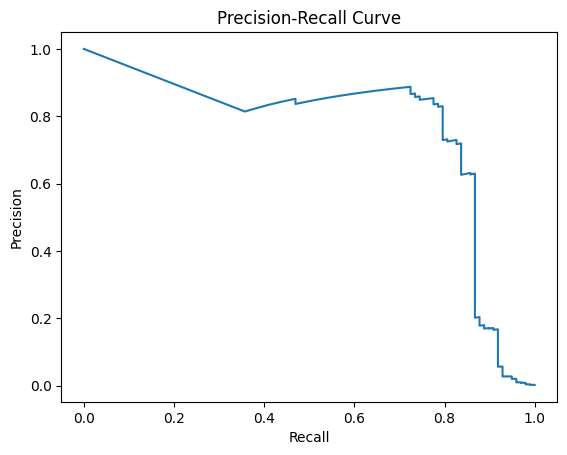

In [18]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
avg_precision = average_precision_score(y_test, y_probs)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()